# TP N° 3 : Gestion des Valeurs Manquantes


### Exploration Initiale du Dataset

In [170]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

In [197]:
df = pd.read_csv("titanic.csv")

In [172]:
print(df.shape)

(891, 12)


In [173]:
print(df.isnull().sum())
# oui il y a des valeurs manquantes dans les colonnes age cabin et embarked

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


### Analyse et Traitement des Valeurs Manquantes


In [174]:
# cats mode num median if there is some outliers and avg in normal case 

In [175]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


<Axes: >

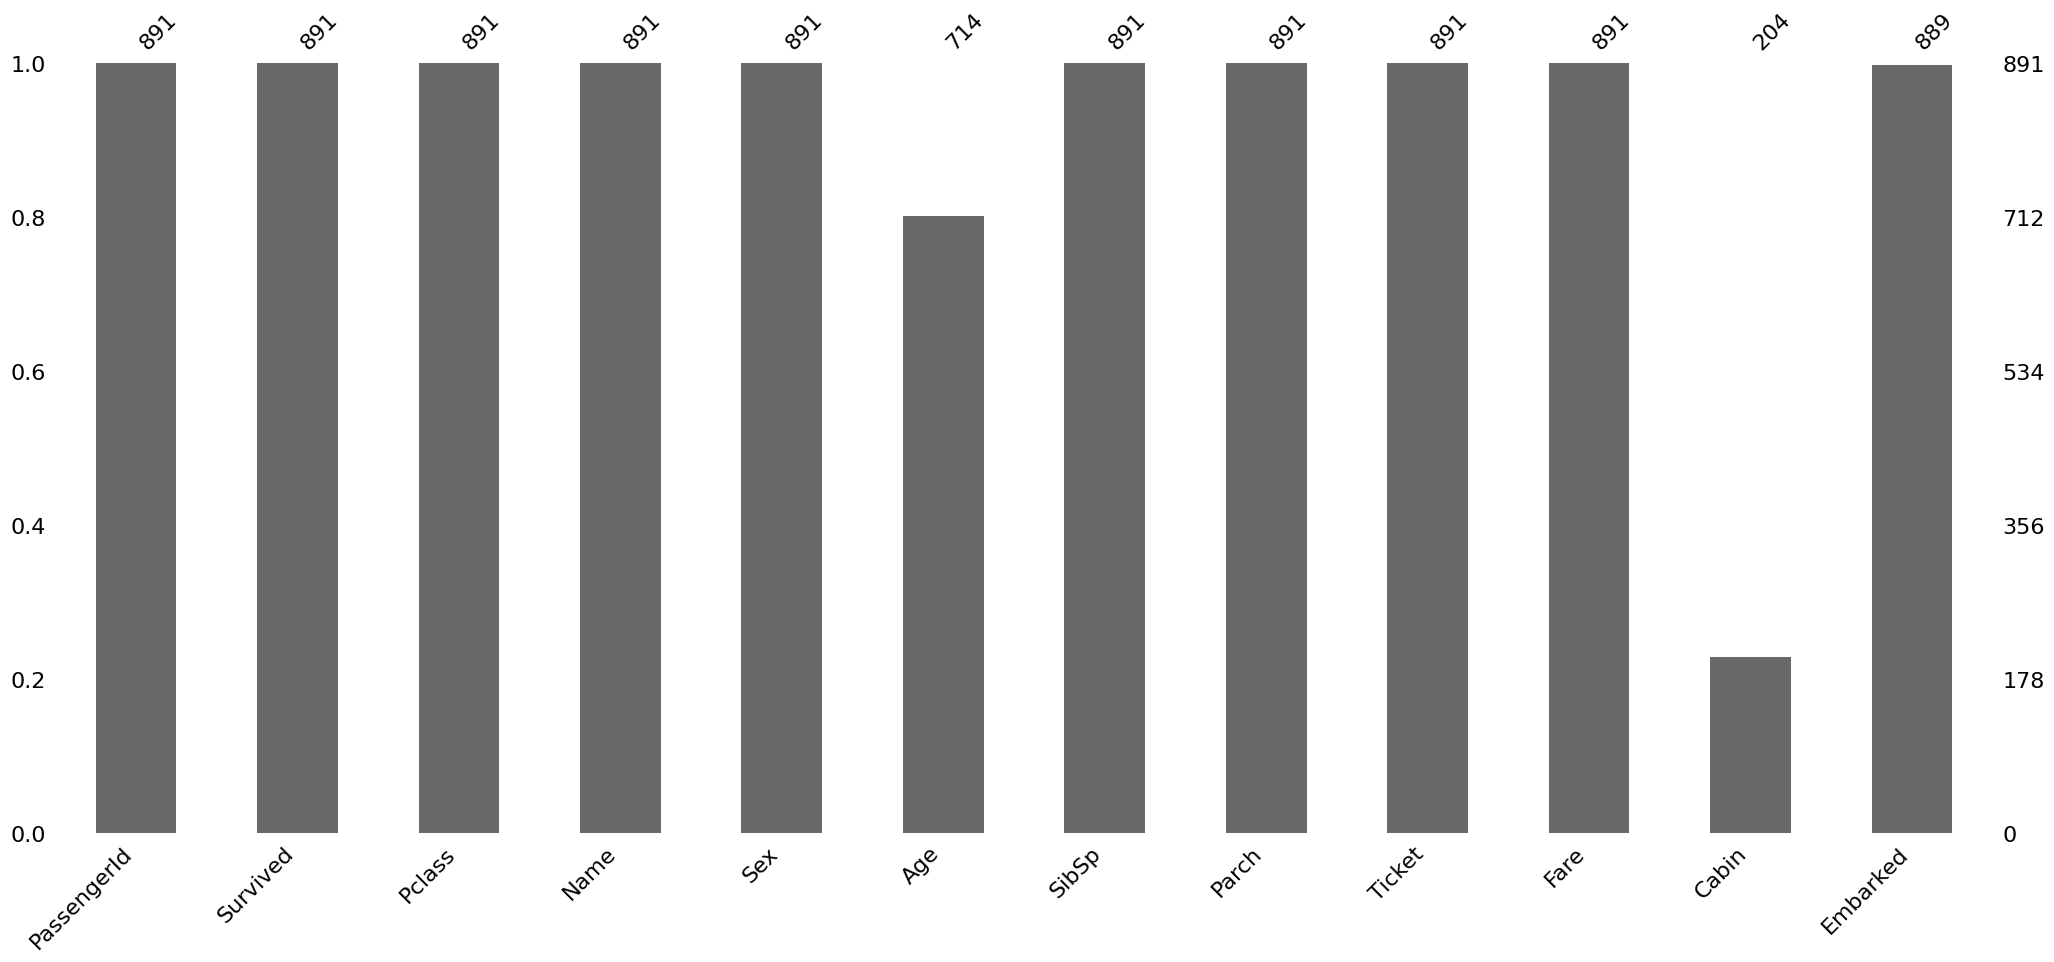

In [176]:
msno.bar(df)

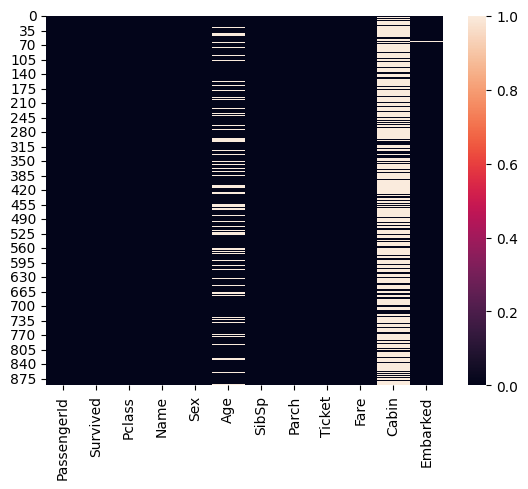

In [177]:
sns.heatmap(df.isnull())
plt.show()

In [198]:
df = df.dropna(axis=0, how="any")  # 0 for rows and 1 for cols
print(df.shape)

(183, 12)


In [199]:
df = df.dropna(subset=["Embarked"],how='any')
print(df.shape)

(183, 12)


In [200]:
df = df.drop(columns=["Cabin"])
print(df.shape)

(183, 11)


In [181]:
# min age 0.92 max 80 so we're having outliers
df["Age"] = df["Age"].fillna(df["Age"].median())
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [182]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
print(df["Embarked"].isnull().sum())

0


In [183]:
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


forward fill or ffill is filling the missing data with the last valid one in the other hand
backward fill or bfill usese the next valid 

In [184]:
df["Age"] = df["Age"].ffill()
# or bfill

In [185]:
df["Age"] = df["Age"].interpolate(method='linear',limit_direction='both')

In [190]:
from sklearn.linear_model import LinearRegression

feats = ['Pclass','SibSp','Parch','Fare']
target = 'Age'
train_data = df[df[target].notnull()]
predict_data = df[df[target].isnull()]
X_train = train_data[feats]
y_train = train_data[target]
X_predict = predict_data[feats]
model = LinearRegression()
model.fit(X_train,y_train)
predicted_ages = model.predict(X_predict)
df.loc[df[target].isnull(), target] = predicted_ages
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       2
dtype: int64


In [ ]:
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

numeric_cols = df.select_dtypes(include='number').columns.tolist()
num_df = df[numeric_cols]
scaler = MinMaxScaler()
num_scaled = scaler.fit_transform(num_df)
imputer = KNNImputer(n_neighbors=5)
num_imputed = imputer.fit_transform(num_scaled)
df_imputed = pd.DataFrame(num_imputed, columns=numeric_cols)
df_imputed = pd.DataFrame(
    scaler.inverse_transform(df_imputed),
    columns=numeric_cols
)
df["Age"] = df_imputed["Age"]
print(df["Age"].isnull().sum())

0


In [ ]:

from sklearn.tree import DecisionTreeRegressor
from sklearn.preprocessing import LabelEncoder
df_dt = df.copy()
for col in df_dt.select_dtypes(include=['object', 'string']).columns:
    df_dt[col] = LabelEncoder().fit_transform(df_dt[col].astype(str))
train_df = df_dt[df_dt["Age"].notnull()]
test_df = df_dt[df_dt["Age"].isnull()]
X_train = train_df.drop("Age", axis=1)
y_train = train_df["Age"]
X_test = test_df.drop("Age", axis=1)
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)
predicted_age = model.predict(X_test)
df.loc[df["Age"].isnull(), "Age"] = predicted_age
print(df["Age"].isnull().sum())

0


# TP N° 4 : Détection des Valeurs Aberrantes et Data Skewness


Les valeurs aberrantes peuvent biaiser la moyenne et l’écart-type et influencer fortement les modèles sensibles comme régression linéaire ,KNN, SVM, réseaux de neurones etc ...

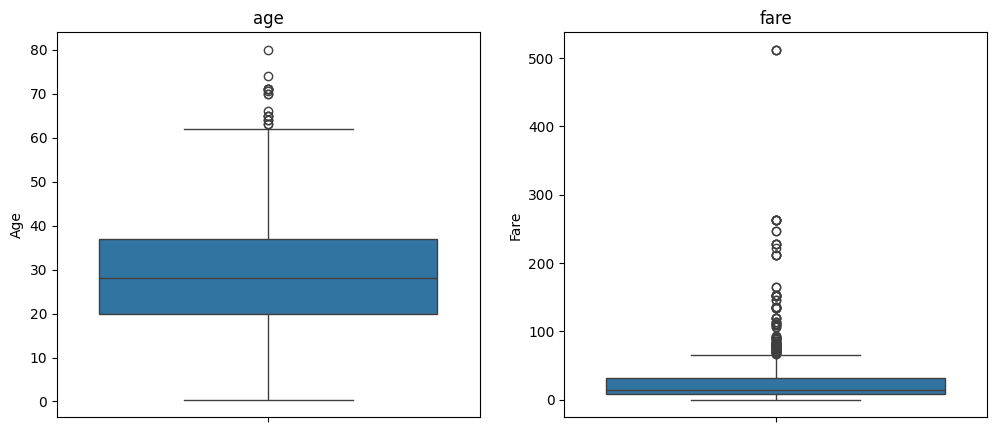

In [ ]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(y=df["Age"])
plt.title("age")
plt.subplot(1,2,2)
sns.boxplot(y=df["Fare"])
plt.title("fare")
plt.show()

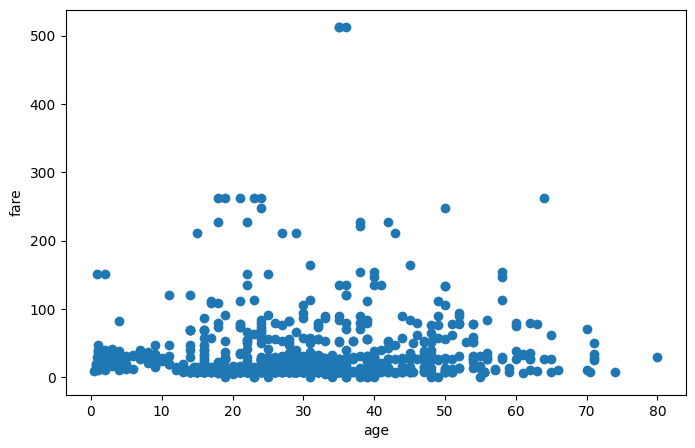

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(df["Age"], df["Fare"])
plt.xlabel("age")
plt.ylabel("fare")
plt.show()

In [ ]:
from scipy.stats import zscore
df["age_zscore"] = zscore(df["Age"])
df["fare_zscore"] = zscore(df["Fare"])
age_outliers_z = df[df["age_zscore"].abs() > 3]
fare_outliers_z = df[df["fare_zscore"].abs() > 3]
print("outliers of age (z-score):", len(age_outliers_z))
print("outliers of fare:", len(fare_outliers_z))

outliers of age (z-score): 2
outliers of fare: 20


isolation forest est adaptée car il fonctionne bien sur grands datasets, ne suppose pas une distribution normale et isole rapidement les points rares

In [ ]:
from sklearn.ensemble import IsolationForest
iso = IsolationForest(contamination=0.05, random_state=42)
df["iso_outlier"] = iso.fit_predict(df[["Age", "Fare"]])
outliers_iso = df[df["iso_outlier"] == -1]
print("number of outliers:", len(outliers_iso))
print(outliers_iso[["Age", "Fare"]].head())
# -1 outlier 1 normal

number of outliers: 45
      Age      Fare
27   19.0  263.0000
54   65.0   61.9792
88   23.0  263.0000
96   71.0   34.6542
118  24.0  247.5208


l'equation de l'iqr est iqr = q3 - q1

In [ ]:
Q1_age = df["Age"].quantile(0.25)
Q3_age = df["Age"].quantile(0.75)
IQR_age = Q3_age - Q1_age
lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age
age_outliers_iqr = df[(df["Age"] < lower_age) | (df["Age"] > upper_age)]
print("age outliers:", len(age_outliers_iqr))
Q1_fare = df["Fare"].quantile(0.25)
Q3_fare = df["Fare"].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare
fare_outliers_iqr = df[(df["Fare"] < lower_fare) | (df["Fare"] > upper_fare)]
print("fare outliers:", len(fare_outliers_iqr))

age outliers: 17
fare outliers: 116


la skewness mesure l’asymétrie d’une distribution.

In [ ]:
print(df["Fare"].skew())
print(df["Age"].skew())

4.787316519674893
0.49190792475295075


car beaucoup de passagers ont payé peu et quelques passagers ont payé énormément

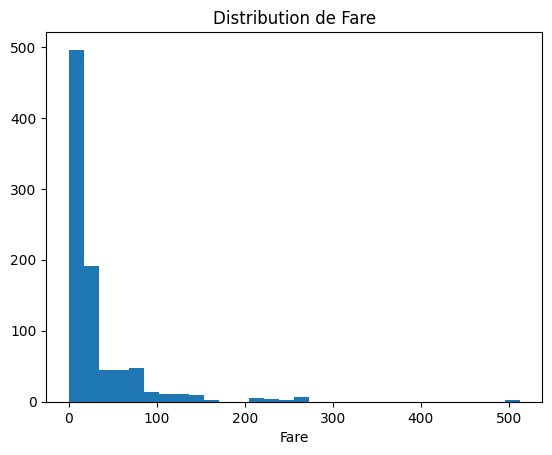

In [ ]:
plt.hist(df["Fare"], bins=30)
plt.title("Distribution de Fare")
plt.xlabel("Fare")
plt.show()

la distribution est asymétrique positive on a que la majorité des valeurs faibles et quelques très grandes valeurs

Une skewness positive indique une « queue » étirée vers la droite (valeurs élevées) avec la majorité des données à gauche. Une skewness négative montre une « queue » étirée vers la gauche (valeurs faibles), avec la majorité des données à droite

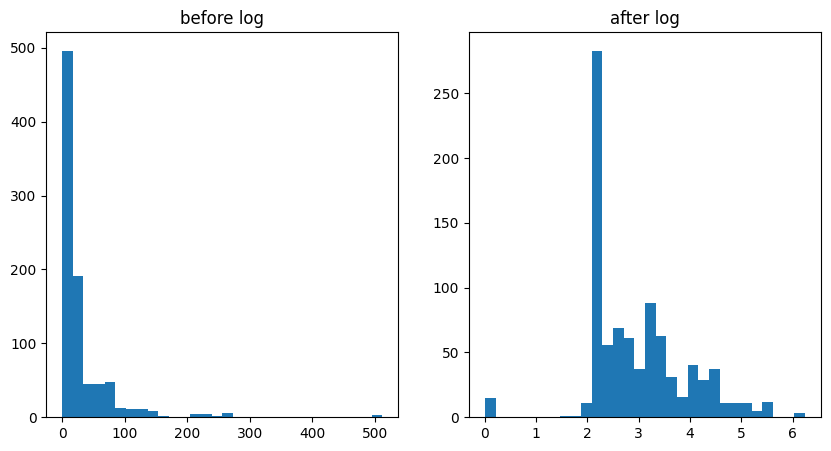

skewness before: 4.787316519674893
skewness after: 0.3949280095189306


In [ ]:
import numpy as np
df["fare_log"] = np.log1p(df["Fare"])
plt.figure(figsize=(10,5))
plt.subplot(1,2,1)
plt.hist(df["Fare"], bins=30)
plt.title("before log")
plt.subplot(1,2,2)
plt.hist(df["fare_log"], bins=30)
plt.title("after log")
plt.show()
print("skewness before:", df["Fare"].skew())
print("skewness after:", df["Fare_log"].skew())

après transformation logarithmique la skewness diminue, la distribution devient plus proche de normale et on a
moins d’influence des grandes valeurs